# NYC Neighborhood Pulse
## Notebook 01 — Data Loading & Preprocessing

**Goal**: Load Airbnb listings + reviews, merge them, filter & sample, save clean dataset for NLP.

**Output**: `outputs/merged_reviews.csv`

## 0. Install Dependencies

In [1]:
# Run once to install required packages
# !pip install pandas geopandas langdetect tqdm

## 1. Import & Config

In [2]:
import pandas as pd
import os
from tqdm import tqdm

# ── Path Config ──────────────────────────────────────────
BASE_DIR   = os.getcwd()          # folder where this notebook lives
DATA_DIR   = BASE_DIR             # listings.csv & reviews.csv are here
OUTPUT_DIR = os.path.join(BASE_DIR, 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

LISTINGS_PATH = os.path.join(DATA_DIR, 'listings.csv')
REVIEWS_PATH  = os.path.join(DATA_DIR, 'reviews.csv')

print('Data dir :', DATA_DIR)
print('Output dir:', OUTPUT_DIR)

Data dir : /Users/georgecai/Desktop/Data Visualization Final Project
Output dir: /Users/georgecai/Desktop/Data Visualization Final Project/outputs


## 2. Load Listings — keep only needed columns

In [3]:
LISTING_COLS = [
    'id',
    'neighbourhood_cleansed',       # neighborhood name
    'neighbourhood_group_cleansed', # borough
    'latitude',
    'longitude',
    'room_type',
    'price',
    'number_of_reviews',
]

listings = pd.read_csv(LISTINGS_PATH, usecols=LISTING_COLS, low_memory=False)
listings.rename(columns={
    'id': 'listing_id',
    'neighbourhood_cleansed':       'neighborhood',
    'neighbourhood_group_cleansed': 'borough',
}, inplace=True)

print(f'Listings loaded: {len(listings):,} rows')
listings.head(3)

Listings loaded: 36,445 rows


,listing_id,neighborhood,borough,latitude,longitude,room_type,price,number_of_reviews
0,2595,Midtown,Manhattan,40.75356,-73.98559,Entire home/apt,NaN,47
1,6848,Williamsburg,Brooklyn,40.70935,-73.95342,Entire home/apt,NaN,197
2,6872,East Harlem,Manhattan,40.80107,-73.94255,Private room,NaN,2


In [4]:
# Borough distribution
print('Borough counts:')
print(listings['borough'].value_counts())
print(f'\nUnique neighborhoods: {listings["neighborhood"].nunique()}')

Borough counts:
borough
Manhattan        16355
Brooklyn         13254
Queens            5329
Bronx             1138
Staten Island      369
Name: count, dtype: int64

Unique neighborhoods: 224


## 3. Load Reviews

In [5]:
REVIEW_COLS = ['listing_id', 'id', 'date', 'comments']

reviews = pd.read_csv(REVIEWS_PATH, usecols=REVIEW_COLS, low_memory=False)
reviews.rename(columns={'id': 'review_id'}, inplace=True)
reviews['date'] = pd.to_datetime(reviews['date'], errors='coerce')

print(f'Reviews loaded: {len(reviews):,} rows')
reviews.head(3)

Reviews loaded: 1,003,480 rows


,listing_id,review_id,date,comments
0,2595,17857,2009-11-21,Notre séjour de trois nuits.\r<br/>Nous avons ...
1,2595,19176,2009-12-05,Great experience.
2,2595,46312,2010-05-25,We had a wonderful stay at Jennifer's charming...


## 4. Merge: Reviews ← join → Listings

In [6]:
df = reviews.merge(
    listings[['listing_id', 'neighborhood', 'borough', 'latitude', 'longitude', 'room_type']],
    on='listing_id',
    how='inner'
)

print(f'Merged dataset: {len(df):,} rows')
print(f'Columns: {list(df.columns)}')
df.head(3)

Merged dataset: 1,003,480 rows
Columns: ['listing_id', 'review_id', 'date', 'comments', 'neighborhood', 'borough', 'latitude', 'longitude', 'room_type']


,listing_id,review_id,date,comments,neighborhood,borough,latitude,longitude,room_type
0,2595,17857,2009-11-21,Notre séjour de trois nuits.\r<br/>Nous avons ...,Midtown,Manhattan,40.75356,-73.98559,Entire home/apt
1,2595,19176,2009-12-05,Great experience.,Midtown,Manhattan,40.75356,-73.98559,Entire home/apt
2,2595,46312,2010-05-25,We had a wonderful stay at Jennifer's charming...,Midtown,Manhattan,40.75356,-73.98559,Entire home/apt


## 5. Filter — clean text, date range, English only

In [7]:
print(f'Before filtering: {len(df):,}')

# 5a. Drop nulls & very short comments
df = df.dropna(subset=['comments'])
df = df[df['comments'].str.len() > 50]   # at least 50 chars
print(f'After length filter: {len(df):,}')

# 5b. Keep only recent reviews (2022 onwards) for relevance
df = df[df['date'] >= '2022-01-01']
print(f'After date filter (2022+): {len(df):,}')

Before filtering: 1,003,480
After length filter: 858,381
After date filter (2022+): 470,659


In [8]:
# 5c. Language detection — keep English only
# This step takes ~5 minutes; skip if you want to move fast (most reviews are English)

RUN_LANG_DETECT = False   # ← set True to enable

if RUN_LANG_DETECT:
    from langdetect import detect, LangDetectException

    def safe_detect(text):
        try:
            return detect(str(text))
        except LangDetectException:
            return 'unknown'

    tqdm.pandas(desc='Detecting language')
    df['lang'] = df['comments'].progress_apply(safe_detect)
    df = df[df['lang'] == 'en']
    print(f'After English filter: {len(df):,}')
else:
    print('Language detection skipped — assuming mostly English')

Language detection skipped — assuming mostly English


## 6. Stratified Sample — cap at 150k reviews (BERTopic sweet spot)

In [9]:
SAMPLE_SIZE = 150_000

if len(df) > SAMPLE_SIZE:
    # Stratified by neighborhood so smaller neighborhoods aren't lost
    df = (
        df.groupby('neighborhood', group_keys=False)
          .apply(lambda x: x.sample(
              n=max(1, int(len(x) / len(df) * SAMPLE_SIZE)),
              random_state=42
          ))
    )
    print(f'After stratified sampling: {len(df):,}')
else:
    print(f'No sampling needed, dataset size: {len(df):,}')

df = df.reset_index(drop=True)

After stratified sampling: 149,903


/var/folders/d8/p3l6lrbx3t99x52zv7k2tnmm0000gn/T/ipykernel_84615/2885781418.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


## 7. Quick EDA

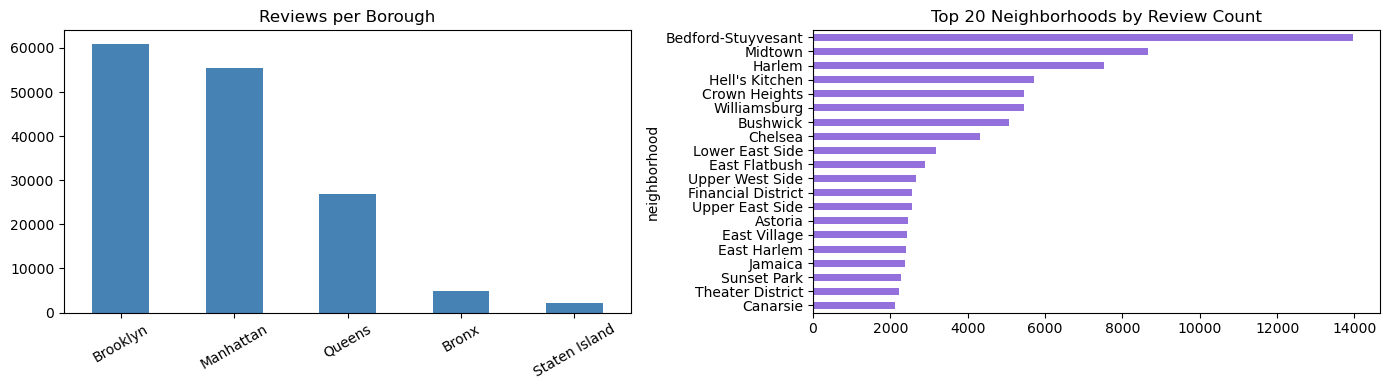

Chart saved to outputs/


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Reviews per borough
df['borough'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Reviews per Borough')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# Top 20 neighborhoods
df['neighborhood'].value_counts().head(20).plot(
    kind='barh', ax=axes[1], color='mediumpurple'
)
axes[1].set_title('Top 20 Neighborhoods by Review Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_review_distribution.png'), dpi=150)
plt.show()
print('Chart saved to outputs/')

In [11]:
# Neighborhood coverage summary
neigh_stats = (
    df.groupby(['borough', 'neighborhood'])
      .agg(review_count=('review_id', 'count'))
      .reset_index()
      .sort_values('review_count', ascending=False)
)
print(f'Neighborhoods with data: {neigh_stats["neighborhood"].nunique()} / 224')
print(f'Min reviews per neighborhood: {neigh_stats["review_count"].min()}')
print(f'Max reviews per neighborhood: {neigh_stats["review_count"].max()}')
neigh_stats.head(10)

Neighborhoods with data: 220 / 224
Min reviews per neighborhood: 1
Max reviews per neighborhood: 13961


,borough,neighborhood,review_count
51,Brooklyn,Bedford-Stuyvesant,13961
114,Manhattan,Midtown,8672
107,Manhattan,Harlem,7515
108,Manhattan,Hell's Kitchen,5716
66,Brooklyn,Crown Heights,5454
95,Brooklyn,Williamsburg,5447
59,Brooklyn,Bushwick,5055
98,Manhattan,Chelsea,4304
112,Manhattan,Lower East Side,3182
71,Brooklyn,East Flatbush,2896


## 8. Save

In [12]:
out_path = os.path.join(OUTPUT_DIR, 'merged_reviews.csv')
df.to_csv(out_path, index=False)
print(f'✅ Saved: {out_path}')
print(f'   Rows   : {len(df):,}')
print(f'   Columns: {list(df.columns)}')

✅ Saved: /Users/georgecai/Desktop/Data Visualization Final Project/outputs/merged_reviews.csv
   Rows   : 149,903
   Columns: ['listing_id', 'review_id', 'date', 'comments', 'neighborhood', 'borough', 'latitude', 'longitude', 'room_type']


---
## ✅ Notebook 01 Complete

Output saved to `outputs/merged_reviews.csv`.

**Next**: Run `02_nlp_processing.ipynb` for BERTopic modeling.